In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [29]:
df = pd.read_csv("/kaggle/input/datasets/laotse/credit-risk-dataset/credit_risk_dataset.csv")
print(df)

       person_age  person_income person_home_ownership  person_emp_length  \
0              22          59000                  RENT              123.0   
1              21           9600                   OWN                5.0   
2              25           9600              MORTGAGE                1.0   
3              23          65500                  RENT                4.0   
4              24          54400                  RENT                8.0   
...           ...            ...                   ...                ...   
32576          57          53000              MORTGAGE                1.0   
32577          54         120000              MORTGAGE                4.0   
32578          65          76000                  RENT                3.0   
32579          56         150000              MORTGAGE                5.0   
32580          66          42000                  RENT                2.0   

           loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [31]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [32]:
print(df.head())

   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y                           3  


In [33]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [34]:
df["person_emp_length"] = df["person_emp_length"].fillna(df["person_emp_length"].median())
print(df["person_emp_length"])
df["loan_int_rate"] = df["loan_int_rate"].fillna(df["loan_int_rate"].median())
print(df["loan_int_rate"])

0        123.0
1          5.0
2          1.0
3          4.0
4          8.0
         ...  
32576      1.0
32577      4.0
32578      3.0
32579      5.0
32580      2.0
Name: person_emp_length, Length: 32581, dtype: float64
0        16.02
1        11.14
2        12.87
3        15.23
4        14.27
         ...  
32576    13.16
32577     7.49
32578    10.99
32579    11.48
32580     9.99
Name: loan_int_rate, Length: 32581, dtype: float64


In [35]:
df.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [36]:
print(df["person_home_ownership"].unique())
print(df["loan_intent"].unique())
print(df["loan_grade"].unique())
print(df["cb_person_default_on_file"].unique())

['RENT' 'OWN' 'MORTGAGE' 'OTHER']
['PERSONAL' 'EDUCATION' 'MEDICAL' 'VENTURE' 'HOMEIMPROVEMENT'
 'DEBTCONSOLIDATION']
['D' 'B' 'C' 'A' 'E' 'F' 'G']
['Y' 'N']


In [37]:
df = pd.get_dummies(
    df,
    columns=["person_home_ownership", "loan_intent", "loan_grade"],
    drop_first=True,
    dtype=int
)
print(df)

       person_age  person_income  person_emp_length  loan_amnt  loan_int_rate  \
0              22          59000              123.0      35000          16.02   
1              21           9600                5.0       1000          11.14   
2              25           9600                1.0       5500          12.87   
3              23          65500                4.0      35000          15.23   
4              24          54400                8.0      35000          14.27   
...           ...            ...                ...        ...            ...   
32576          57          53000                1.0       5800          13.16   
32577          54         120000                4.0      17625           7.49   
32578          65          76000                3.0      35000          10.99   
32579          56         150000                5.0      15000          11.48   
32580          66          42000                2.0       6475           9.99   

       loan_status  loan_pe

In [38]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["cb_person_default_on_file"] = le.fit_transform(df["cb_person_default_on_file"])
print(df)

       person_age  person_income  person_emp_length  loan_amnt  loan_int_rate  \
0              22          59000              123.0      35000          16.02   
1              21           9600                5.0       1000          11.14   
2              25           9600                1.0       5500          12.87   
3              23          65500                4.0      35000          15.23   
4              24          54400                8.0      35000          14.27   
...           ...            ...                ...        ...            ...   
32576          57          53000                1.0       5800          13.16   
32577          54         120000                4.0      17625           7.49   
32578          65          76000                3.0      35000          10.99   
32579          56         150000                5.0      15000          11.48   
32580          66          42000                2.0       6475           9.99   

       loan_status  loan_pe

In [39]:
# Impossible employment length ko drop karne ke liye:
df = df[df['person_emp_length'] <= 60]

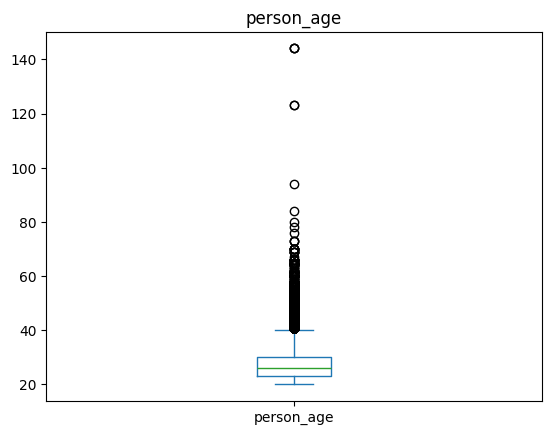

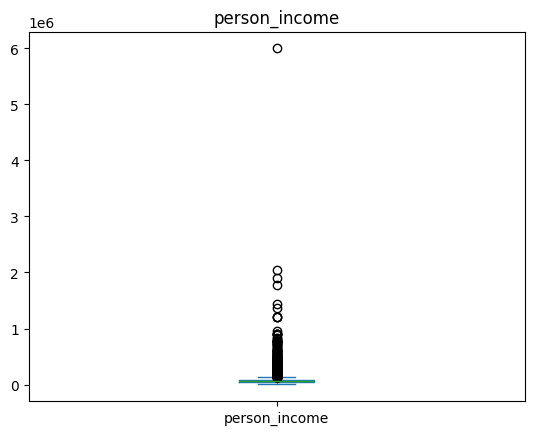

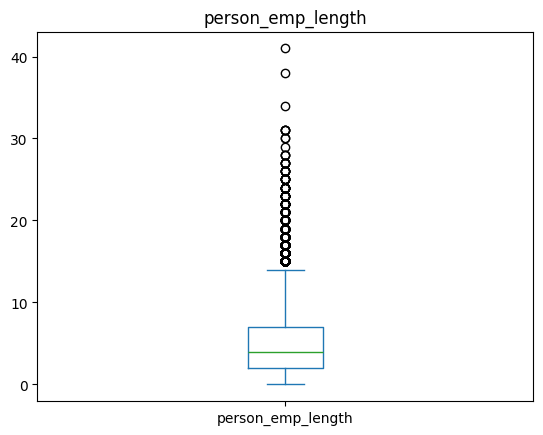

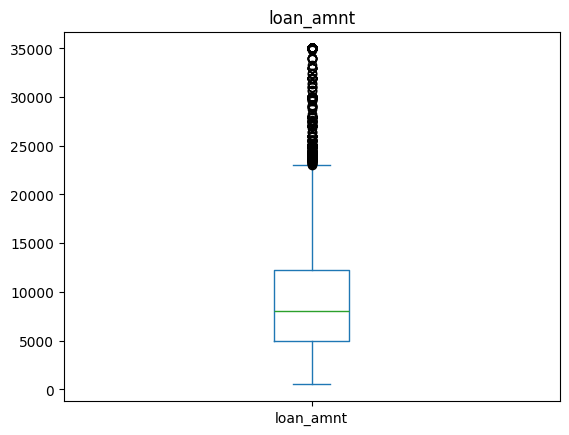

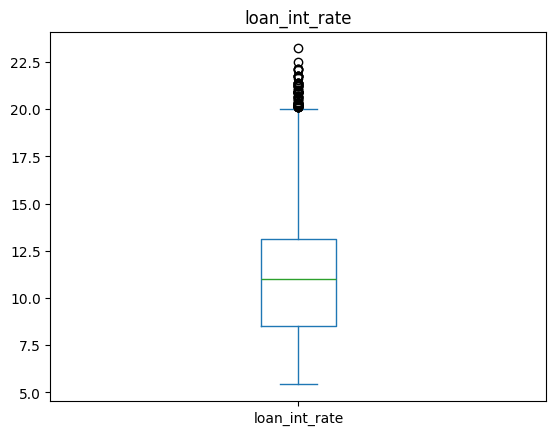

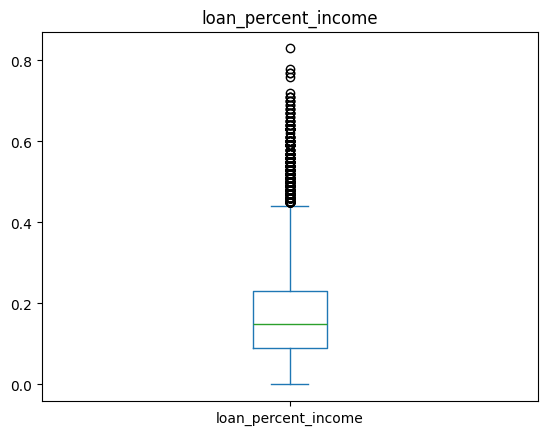

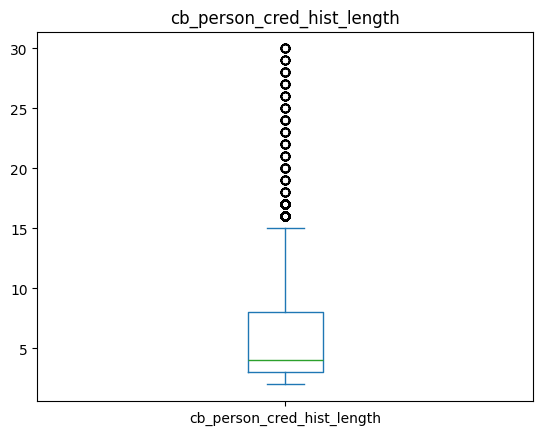

In [40]:
columns = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length"
]

for col in columns:
    df[col].plot(kind="box")
    plt.title(col)
    plt.show()

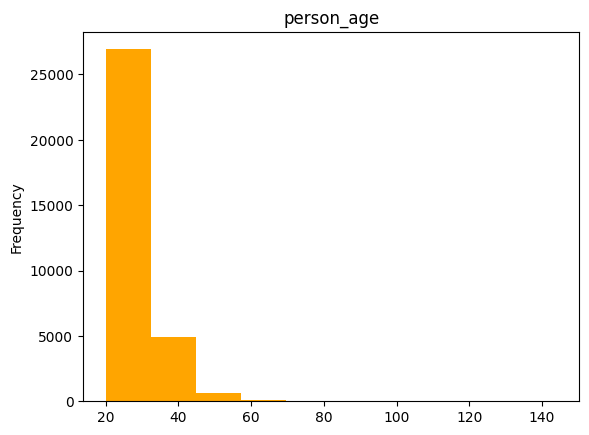

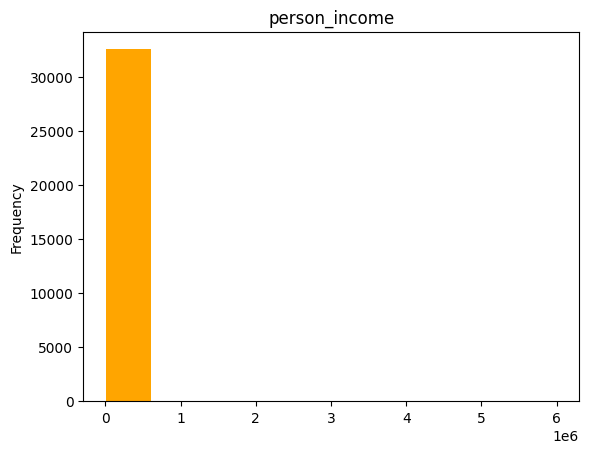

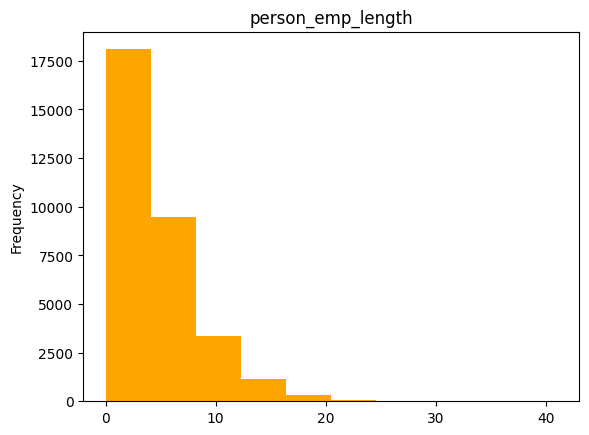

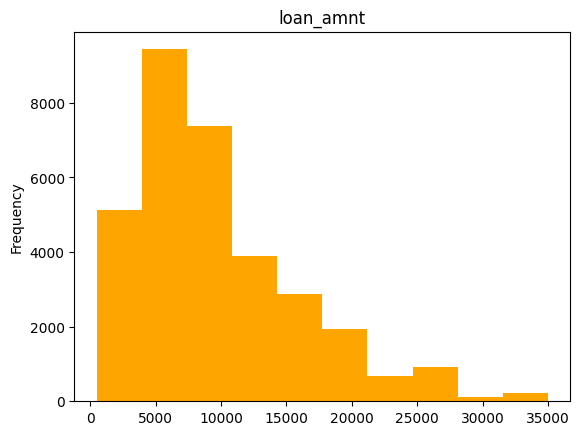

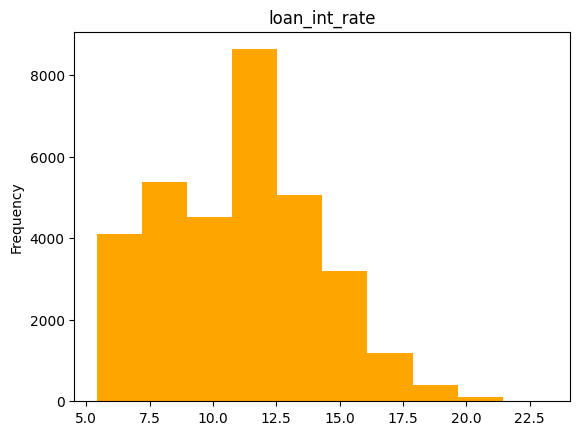

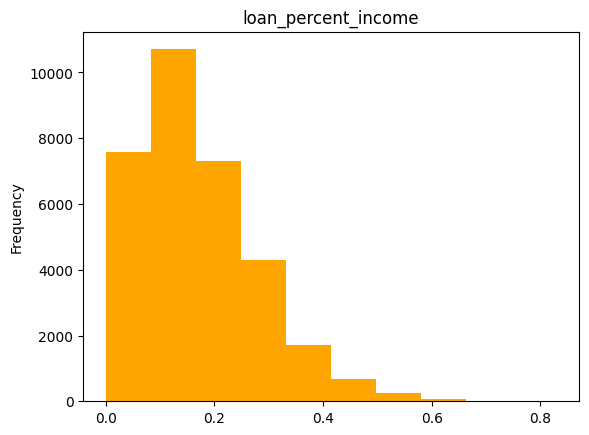

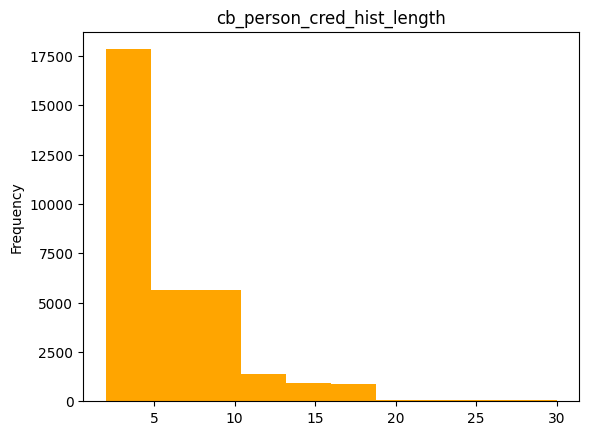

In [41]:
columns = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length"
]

for col in columns:
    df[col].plot(kind="hist",color="orange")
    plt.title(col)
    plt.show()

In [42]:
X = df[["person_age","person_income","person_emp_length","loan_amnt","loan_int_rate","loan_percent_income","cb_person_cred_hist_length"]]
y = df["loan_status"]

In [43]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)
print(x_scaled)

[[-1.06096358 -0.91111779  0.06010056 ...  0.04231685 -0.65749814
  -0.93818311]
 [-0.43084253 -0.91111779 -0.94465442 ...  0.60374378  3.74500884
  -0.69157528]
 [-0.74590306 -0.00921586 -0.19108818 ...  1.36962099  3.3703274
  -0.93818311]
 ...
 [ 5.87036792  0.16019326 -0.44227693 ... -0.00636179  2.71463487
   5.47362043]
 [ 4.45259557  1.35412426  0.06010056 ...  0.15265509 -0.65749814
   4.98040477]
 [ 6.02789818 -0.38836962 -0.69346567 ... -0.33088603 -0.18914633
   5.96683609]]


In [44]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(x_scaled,y,test_size=0.40,random_state=42)
print(X_train.shape)
print(X_test.shape)

(19547, 7)
(13032, 7)


In [45]:
from sklearn.tree import DecisionTreeClassifier
decisiontree = DecisionTreeClassifier(max_depth=5,min_samples_split=5,min_samples_leaf=5,random_state=42)
decisiontree.fit(X_train,y_train)
y1_predict = decisiontree.predict(X_test)
y1_pred_prob =decisiontree.predict_proba(X_test)
print(y1_pred_prob)
print(y1_predict)
print(y_test)

[[0.26326964 0.73673036]
 [0.90227082 0.09772918]
 [0.90227082 0.09772918]
 ...
 [0.90227082 0.09772918]
 [0.96034509 0.03965491]
 [0.96034509 0.03965491]]
[1 0 0 ... 0 0 0]
14449    1
24615    0
11098    0
10426    1
12630    0
        ..
4335     1
12932    0
4603     0
350      0
12815    0
Name: loan_status, Length: 13032, dtype: int64


In [46]:
from sklearn.linear_model import LogisticRegression
logiregression = LogisticRegression()
logiregression.fit(X_train,y_train)
y2_predict = logiregression.predict(X_test) 
print(y2_predict)
print(y_test)

[1 0 0 ... 0 0 0]
14449    1
24615    0
11098    0
10426    1
12630    0
        ..
4335     1
12932    0
4603     0
350      0
12815    0
Name: loan_status, Length: 13032, dtype: int64


In [47]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100,random_state=42) 
rf.fit(X_train,y_train)
rf_predict = rf.predict(X_test)
print(rf_predict)

[1 0 0 ... 0 0 0]


In [48]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
print("evaluation of decision tree")
accuray_decisiontree = accuracy_score(y_test,y1_predict)*100
print("ACCURACY IS =", accuray_decisiontree)
print("PRECISION IS = ",precision_score(y_test,y1_predict)*100)
print("RECALL IS =",recall_score(y_test,y1_predict)*100)
print("confusion matrix =\n",confusion_matrix(y_test,y1_predict))
print("classification report=\n",classification_report(y_test,y1_predict))


print("evaluation of logistic regression")
accuracy_logisticregresson = accuracy_score(y_test,y2_predict)*100
print("ACCURACY IS = ",accuracy_logisticregresson)
print("PRECISION IS = ",precision_score(y_test,y2_predict)*100)
print("RECALL IS =",recall_score(y_test,y2_predict)*100)
print("confusion matrix =\n",confusion_matrix(y_test,y2_predict))
print("classification report=\n",classification_report(y_test,y2_predict))


print("evaluation of random forest")
accuracy_randomforest = accuracy_score(y_test,rf_predict)*100
print("ACCURACY IS = ",accuracy_randomforest)
print("PRECISION IS = ",precision_score(y_test,rf_predict)*100)
print("RECALL IS =",recall_score(y_test,rf_predict)*100)
print("confusion matrix =\n",confusion_matrix(y_test,rf_predict))
print("classification report=\n",classification_report(y_test,rf_predict))


evaluation of decision tree
ACCURACY IS = 85.97298956414978
PRECISION IS =  71.3436385255648
RECALL IS = 61.96213425129088
confusion matrix =
 [[9404  723]
 [1105 1800]]
classification report=
               precision    recall  f1-score   support

           0       0.89      0.93      0.91     10127
           1       0.71      0.62      0.66      2905

    accuracy                           0.86     13032
   macro avg       0.80      0.77      0.79     13032
weighted avg       0.85      0.86      0.86     13032

evaluation of logistic regression
ACCURACY IS =  82.55831798649479
PRECISION IS =  70.02534854245881
RECALL IS = 38.03786574870912
confusion matrix =
 [[9654  473]
 [1800 1105]]
classification report=
               precision    recall  f1-score   support

           0       0.84      0.95      0.89     10127
           1       0.70      0.38      0.49      2905

    accuracy                           0.83     13032
   macro avg       0.77      0.67      0.69     13032
weigh

In [49]:
train_accuracy_rf = rf.score(X_train,y_train)
test_accuracy_rf = rf.score(X_test,y_test)
print(train_accuracy_rf*100)
print(test_accuracy_rf*100)

train_accuracy_lg = logiregression.score(X_train,y_train)
test_accuracy_lg = logiregression.score(X_test,y_test)
print(train_accuracy_lg*100)
print(test_accuracy_lg*100)

train_accuracy_dt = decisiontree.score(X_train,y_train)
test_accuracy_dt = decisiontree.score(X_test,y_test)
print(train_accuracy_dt*100)
print(test_accuracy_dt*100)


99.98976825088249
86.89379987722529
83.01018059037193
82.55831798649479
86.39688954826828
85.97298956414978


Text(0, 0.5, 'accuracy')

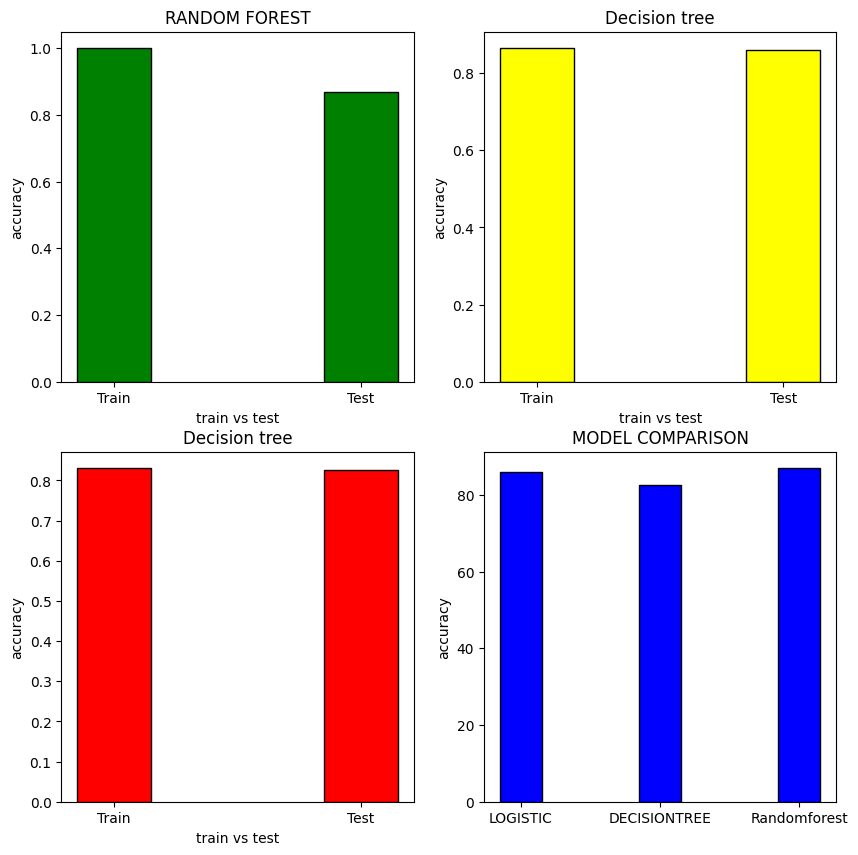

In [50]:
x = ["Train","Test"]
y = [train_accuracy_rf,test_accuracy_rf]
fig,axes = plt.subplots(2,2 ,figsize = (10,10))
axes[0,0].bar(x,y,color="green",edgecolor="black",width=0.3)
axes[0,0].set_title("RANDOM FOREST")
axes[0,0].set_xlabel("train vs test")
axes[0,0].set_ylabel("accuracy")

x = ["Train","Test"]
y = [train_accuracy_dt,test_accuracy_dt]
axes[0,1].bar(x,y,color="YELLOW",edgecolor="black",width=0.3)
axes[0,1].set_title("Decision tree")
axes[0,1].set_xlabel("train vs test")
axes[0,1].set_ylabel("accuracy")

x = ["Train","Test"]
y = [train_accuracy_lg,test_accuracy_lg]
axes[1,0].bar(x,y,color="RED",edgecolor="black",width=0.3)
axes[1,0].set_title("Decision tree")
axes[1,0].set_xlabel("train vs test")
axes[1,0].set_ylabel("accuracy")

x = ["LOGISTIC","DECISIONTREE","Randomforest"]
y = [accuray_decisiontree,accuracy_logisticregresson,accuracy_randomforest]
axes[1,1].bar(x,y,color="BLUE",edgecolor="black",width=0.3)
axes[1,1].set_title("MODEL COMPARISON")
axes[1,1].set_ylabel("accuracy")

LogisticRegression()
[0.82455243 0.82966752 0.82885649 0.82987976 0.8342287 ]
CV_ACCURACY 82.94369803044846
DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, min_samples_split=5,
                       random_state=42)
[0.82429668 0.8028133  0.81325147 0.81325147 0.82885649]
CV_ACCURACY 81.6493880277594
RandomForestClassifier(random_state=42)
[0.87109974 0.86598465 0.87029931 0.87209005 0.87567153]
CV_ACCURACY 87.10290568227691


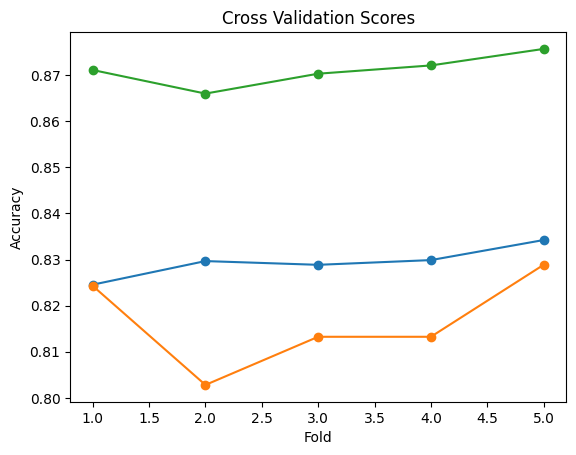

In [51]:
from sklearn.model_selection import cross_val_score
models = {
    logiregression : LogisticRegression(),
    decisiontree : DecisionTreeClassifier(),
    rf : RandomForestClassifier()
}
for name,model in  models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
    print(name)
    print(scores)
    print("CV_ACCURACY",scores.mean()*100)
    plt.plot([1,2,3,4,5],scores, marker="o")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("Cross Validation Scores")
plt.show()

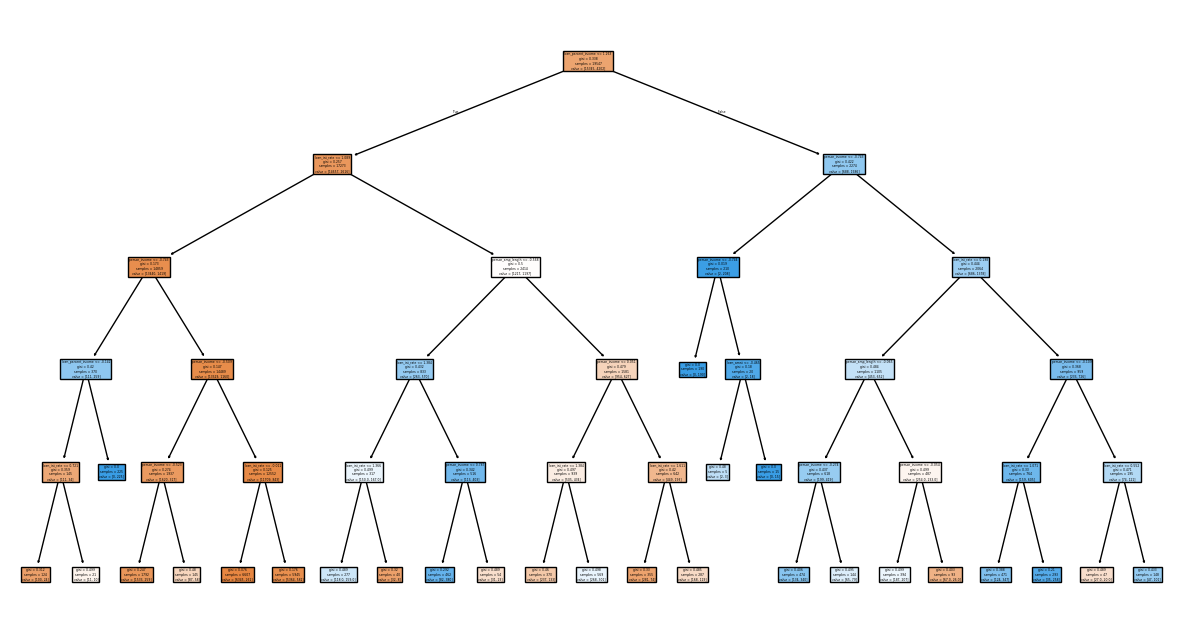

In [52]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))
plot_tree(decisiontree, filled=True, feature_names=X.columns)
plt.show()

Text(0.5, 1.0, 'Loan Status')

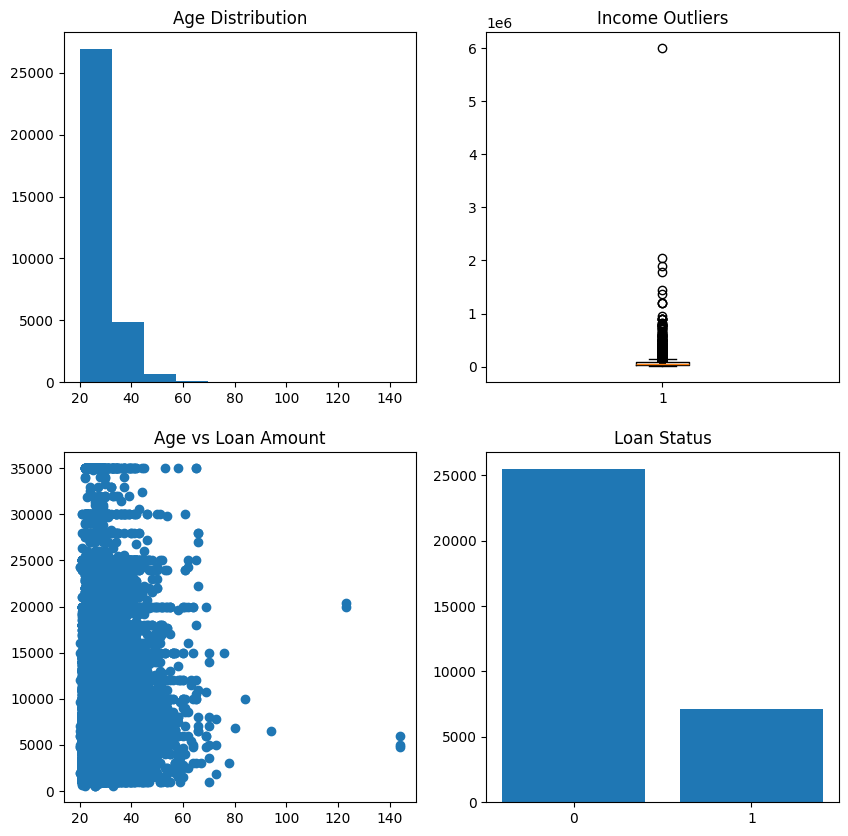

In [53]:
fig, axes = plt.subplots(2, 2, figsize=(10,10))

axes[0,0].hist(df["person_age"])
axes[0,0].set_title("Age Distribution")

axes[0,1].boxplot(df["person_income"])
axes[0,1].set_title("Income Outliers")

axes[1,0].scatter(df["person_age"], df["loan_amnt"])
axes[1,0].set_title("Age vs Loan Amount")

axes[1,1].bar(["0", "1"], df["loan_status"].value_counts())
axes[1,1].set_title("Loan Status")